In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
from transformers import pipeline

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv('archive/call_recordings.csv')

In [5]:
print(df.shape)
print(df.head(3))
print('\nColumns:\n',df.columns.tolist())

(20, 7)
                  id             Type   Sentiment             Name  \
0  call_recording_01  Product Inquiry     Neutral     Sarah Miller   
1  call_recording_02        Complaint       Angry       John Davis   
2  call_recording_03  Technical Issue  Frustrated  Maria Rodriguez   

   Order Number Product Number  \
0           NaN        AC-7892   
1      123456.0        FR-4401   
2      987654.0       LAP-2110   

                                          Transcript  
0  Hello, I'm Sarah Miller. I'm calling to inquir...  
1  I am extremely dissatisfied with my recent ord...  
2  Hi, this is Maria Rodriguez. I'm having troubl...  

Columns:
 ['id', 'Type', 'Sentiment', 'Name', 'Order Number', 'Product Number', 'Transcript']


In [6]:
print(df['Transcript'][0]) 

Hello, I'm Sarah Miller. I'm calling to inquire about the AC-7892 air conditioner unit. I saw it on your website, and I had a few questions. First, what's the BTU rating? And second, does it come with a remote control, or is that sold separately?


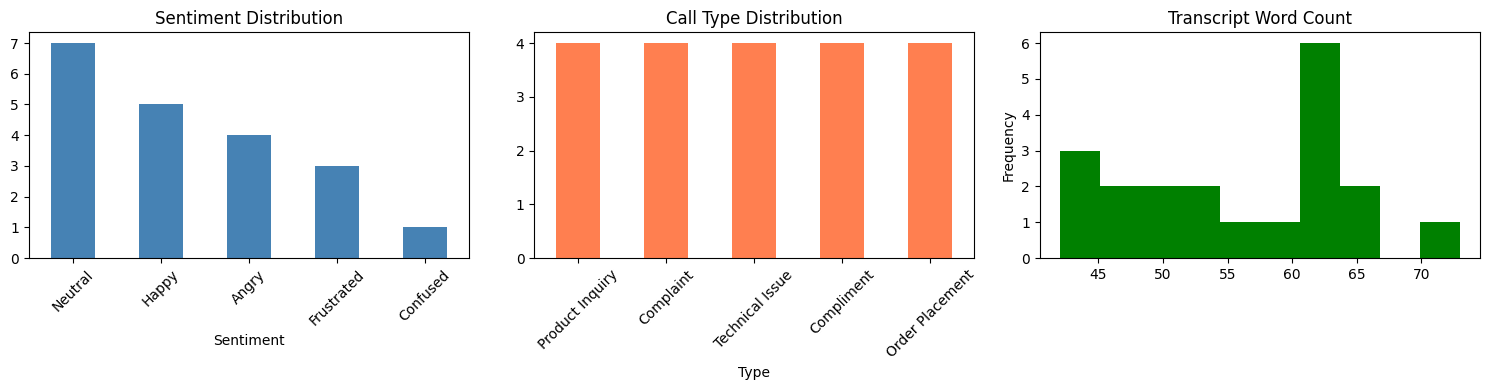

AVG Transcript lenght: 56 words
Missing Values: 
id                   0
Type                 0
Sentiment            0
Name                 0
Order Number         8
Product Number       0
Transcript           0
transcript_lenght    0
dtype: int64


In [7]:
fig, axes =  plt.subplots(1, 3, figsize=(15,4))

# Sentiment Distribution
df['Sentiment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Sentiment Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Call type Distribution
df['Type'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Call Type Distribution')
axes[1].tick_params(axis='x', rotation=45)

# Transcript Lenght
df['transcript_lenght'] = df['Transcript'].apply(lambda x: len(str(x).split()))
df['transcript_lenght'].plot(kind='hist', ax=axes[2], bins=10, color='green')
axes[2].set_title('Transcript Word Count')

plt.tight_layout()
plt.show()

print(f"AVG Transcript lenght: {df['transcript_lenght'].mean():.0f} words")
print(f"Missing Values: \n{df.isnull().sum()}")

In [8]:
nlp = spacy.load('en_core_web_sm')

def redact_pii(row):
    text = str(row['Transcript'])
    
    # Redact name
    if pd.notna(row['Name']):
        name = str(row['Name']).strip()
        text = text.replace(name, '[CUSTOMER_NAME]')
        # first name and last name separately
        parts = name.split()
        for part in parts:
            text = text.replace(part, '[CUSTOMER_NAME]')
    
    # Redact order number
    if pd.notna(row['Order Number']):
        order = str(int(row['Order Number']))
        text = text.replace(order, '[ORDER_NUMBER]')
    
    # Redact product number
    if pd.notna(row['Product Number']):
        text = text.replace(str(row['Product Number']).strip(), '[PRODUCT_NUMBER]')
    
    # redact any remaining numbers that look like order numbers
    text = re.sub(r'\b\d{6}\b', '[ORDER_NUMBER]', text)
    
    return text

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['Redacted_Transcript'] = df.apply(redact_pii, axis=1)
df['NER_Entities'] = df['Transcript'].apply(extract_entities)

for i in range(3):
    print(f"\n--- Call {i+1} ---")
    print(f"ORIGINAL:\n{df['Transcript'][i][:120]}")
    print(f"REDACTED:\n{df['Redacted_Transcript'][i][:120]}")
    print(f"ENTITIES: {df['NER_Entities'][i]}")


--- Call 1 ---
ORIGINAL:
Hello, I'm Sarah Miller. I'm calling to inquire about the AC-7892 air conditioner unit. I saw it on your website, and I 
REDACTED:
Hello, I'm [CUSTOMER_NAME]. I'm calling to inquire about the [PRODUCT_NUMBER] air conditioner unit. I saw it on your web
ENTITIES: [('Sarah Miller', 'PERSON'), ('AC-7892', 'LAW'), ('First', 'ORDINAL'), ('BTU', 'ORG'), ('second', 'ORDINAL')]

--- Call 2 ---
ORIGINAL:
I am extremely dissatisfied with my recent order! I am John Davis, and I'm calling about order number 123456. The FR-440
REDACTED:
I am extremely dissatisfied with my recent order! I am [CUSTOMER_NAME], and I'm calling about order number [ORDER_NUMBER
ENTITIES: [('John Davis', 'PERSON'), ('123456', 'DATE'), ('yesterday', 'DATE'), ('two days', 'DATE')]

--- Call 3 ---
ORIGINAL:
Hi, this is Maria Rodriguez. I'm having trouble with my LAP-2110 laptop, order number 987654. The Wi-Fi keeps disconnect
REDACTED:
Hi, this is [CUSTOMER_NAME]. I'm having trouble with my [PRODUCT_

In [9]:
# Sentiment analysis (HuggingFace)

# Loading pretrained model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_sentiment(text):
  result = sentiment_model(text[:512])[0]
  return result['label'], round(result['score'], 3)

df['predicted_sentiment'], df['sentiment_score'] = zip(*df['Transcript'].apply(get_sentiment))

# compare predicted vs actual
print('\nSentiment Comparison:')
print(df[['Name', 'Sentiment', 'predicted_sentiment', 'sentiment_score']].to_string())

C:\Users\Landl\anaconda3\envs\callcenter\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Sentiment Comparison:
                 Name   Sentiment predicted_sentiment  sentiment_score
0        Sarah Miller     Neutral            NEGATIVE            0.998
1          John Davis       Angry            NEGATIVE            1.000
2     Maria Rodriguez  Frustrated            NEGATIVE            0.924
3        Robert Smith       Happy            POSITIVE            1.000
4       Jessica Brown     Neutral            NEGATIVE            0.980
5        David Wilson    Confused            NEGATIVE            0.997
6        Linda Garcia       Angry            NEGATIVE            1.000
7       Michael Brown     Neutral            NEGATIVE            1.000
8        Amanda White       Happy            POSITIVE            0.992
9   Christopher Green       Happy            POSITIVE            1.000
10   Dr. Emily Carter     Neutral            NEGATIVE            0.984
11          Kevin Lee       Angry            NEGATIVE            0.995
12   Jessica Williams  Frustrated            NEGATIVE 

In [10]:
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
print("Model ready!")

C:\Users\Landl\anaconda3\envs\callcenter\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

C:\Users\Landl\anaconda3\envs\callcenter\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Landl\.cache\huggingface\hub\models--facebook--bart-large-cnn. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model ready!


In [14]:
# Call Summarization
def summarize_call(text):
    if len(text.split()) < 30:
        return 'Transcript too short to summarize'
    result = summarizer(
        text[:1024],
        max_length = 60,
        min_length = 20,
        do_sample = False
    )
    return result[0]['summary_text']

# Running all 20 transcripts
print('\nSummarizing all calls...')
df['Summary'] = df['Transcript'].apply(summarize_call)

# Results
for i in range(3):
    print(f"\n--- Call {i+1} ({df['Type'][i]}) ---")
    print(f"ORIGINAL ({len(df['Transcript'][i].split())} words): {df['Transcript'][i][:150]}...")
    print(f"SUMMARY: {df['Summary'][i]}")


Summarizing all calls...


Your max_length is set to 60, but your input_length is only 56. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=28)



--- Call 1 (Product Inquiry) ---
ORIGINAL (45 words): Hello, I'm Sarah Miller. I'm calling to inquire about the AC-7892 air conditioner unit. I saw it on your website, and I had a few questions. First, wh...
SUMMARY: Sarah Miller calls to inquire about the AC-7892 air conditioner unit. Does it come with a remote control, or is that sold separately? What's the BTU rating?

--- Call 2 (Complaint) ---
ORIGINAL (73 words): I am extremely dissatisfied with my recent order! I am John Davis, and I'm calling about order number 123456. The FR-4401 refrigerator arrived yesterd...
SUMMARY: The FR-4401 refrigerator arrived yesterday, and it's damaged. I demand a replacement, and I want it delivered as soon as possible. I've been without a working refrigerator for two days now!

--- Call 3 (Technical Issue) ---
ORIGINAL (60 words): Hi, this is Maria Rodriguez. I'm having trouble with my LAP-2110 laptop, order number 987654. The Wi-Fi keeps disconnecting, and I can't get a stable ...
SUMMARY: LAP-2

In [17]:
# Keyword Extraction
from keybert import KeyBERT
kw_model = KeyBERT()

def extract_keywords(text):
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1,2),
        stop_words='english',
        top_n=5
    )
    return [kw[0] for kw in keywords]

df['Keywords'] = df['Transcript'].apply(extract_keywords)

print("Keyword Extracted")
for i in range(5):
    print(f"\nCall {i+1} ({df['Type'][i]}): {df['Keywords'][i]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Landl\anaconda3\envs\callcenter\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Landl\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Keyword Extracted

Call 1 (Product Inquiry): ['btu rating', 'air conditioner', 'ac 7892', 'btu', 'remote control']

Call 2 (Complaint): ['4401 refrigerator', 'refrigerator arrived', 'working refrigerator', 'refrigerator', 'fr 4401']

Call 3 (Technical Issue): ['keeps disconnecting', 'disconnecting stable', '2110 laptop', 'lap 2110', 'disconnecting']

Call 4 (Compliment): ['6543 dishwasher', 'best dishwasher', 'dishwasher purchased', 'dishwasher', 'dw 6543']

Call 5 (Order Placement): ['estimated delivery', 'shipping', 'shipping estimated', '8642 microwave', 'including shipping']


In [20]:
# Topic Classification
topic_classifier = pipeline(
    "zero-shot-classification",
    model = "facebook/bart-large-mnli"
)
# topics based on eda
topic_labels = [
    'product inquiry',
    'complaint',
    'technical issue',
    'compliment',
    'order placement'
]

def classify_topic(text):
    result = topic_classifier(
        text[:512],
        candidate_labels=topic_labels
    )
    return result['labels'][0]

print('Classifying topics')
df['Predicted_Topic'] = df['Transcript'].apply(classify_topic)

# Comparing
print('\nTopic Classifcation results')
print(df[['Type', 'Predicted_Topic']].to_string())

# Accuracy
correct = (df['Type'].str.lower() == df['Predicted_Topic'].str.lower()).sum()
print(f"\nAccuracy: {correct}/20 = {correct/20*100:.0f}%")

Classifying topics

Topic Classifcation results
               Type  Predicted_Topic
0   Product Inquiry  product inquiry
1         Complaint        complaint
2   Technical Issue  technical issue
3        Compliment       compliment
4   Order Placement  order placement
5   Product Inquiry  product inquiry
6         Complaint        complaint
7   Technical Issue  technical issue
8   Order Placement  order placement
9        Compliment       compliment
10  Product Inquiry  technical issue
11        Complaint        complaint
12  Technical Issue  technical issue
13  Order Placement  product inquiry
14       Compliment  order placement
15  Product Inquiry  product inquiry
16        Complaint        complaint
17  Technical Issue  technical issue
18  Order Placement  order placement
19       Compliment       compliment

Accuracy: 17/20 = 85%


In [21]:
# Intent Classfication

intent_labels = [
    'get information',
    'file a complaint',
    'request refund',
    'cancel order',
    'track order',
    'get technical support',
    'give positive feedback'
]

def classify_intent(text):
    result = topic_classifier(
        text[:512],
        candidate_labels=intent_labels
    )
    return result['labels'][0]

print('Classifying Intent:')
df['Predicted_Intent'] = df['Transcript'].apply(classify_intent)
print('\nIntent Classifcation results:')
print(df[['Name', 'Type', 'Predicted_Intent']].to_string())

Classifying Intent:

Intent Classifcation results:
                 Name             Type        Predicted_Intent
0        Sarah Miller  Product Inquiry         get information
1          John Davis        Complaint         get information
2     Maria Rodriguez  Technical Issue             track order
3        Robert Smith       Compliment  give positive feedback
4       Jessica Brown  Order Placement         get information
5        David Wilson  Product Inquiry         get information
6        Linda Garcia        Complaint         get information
7       Michael Brown  Technical Issue   get technical support
8        Amanda White  Order Placement  give positive feedback
9   Christopher Green       Compliment  give positive feedback
10   Dr. Emily Carter  Product Inquiry   get technical support
11          Kevin Lee        Complaint        file a complaint
12   Jessica Williams  Technical Issue   get technical support
13       Mike Johnson  Order Placement         get information
14  

In [23]:
# Save processed dataframe
df.to_csv('processed_calls.csv', index=False)
print("Saved to processed_calls.csv")

# Quick summary
print(f"Summarization: {df['Summary'].notna().sum()}/20 calls summarized")
print(f"Keywords: {df['Keywords'].notna().sum()}/20 calls done")
print(f"Topics predicted: {df['Predicted_Topic'].notna().sum()}/20")
print(f"Intents predicted: {df['Predicted_Intent'].notna().sum()}/20")

Saved to processed_calls.csv
Summarization: 20/20 calls summarized
Keywords: 20/20 calls done
Topics predicted: 20/20
Intents predicted: 20/20


In [27]:
df = pd.read_csv('processed_calls.csv')
print(df.columns.tolist())
print(df.shape)

['id', 'Type', 'Sentiment', 'Name', 'Order Number', 'Product Number', 'Transcript', 'transcript_lenght', 'Redacted_Transcript', 'NER_Entities', 'predicted_sentiment', 'sentiment_score', 'Summary', 'Keywords', 'Predicted_Topic', 'Predicted_Intent']
(20, 16)


In [29]:
# Clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [31]:
# Converting transcripts to numbers using TF-IDF
vectorizer = TfidfVectorizer(
    stop_words = 'english',
    max_features=100
)
X = vectorizer.fit_transform(df['Transcript'])
print(f'TF-IDF matrix shape: {X.shape}')

# Applying KMeans
kmeans = KMeans(
    n_clusters = 5,
    random_state = 42,
    n_init = 10
)
df['Cluster'] = kmeans.fit_predict(X)
print(df['Cluster'].value_counts())

TF-IDF matrix shape: (20, 100)
Cluster
3    5
0    5
1    4
2    3
4    3
Name: count, dtype: int64


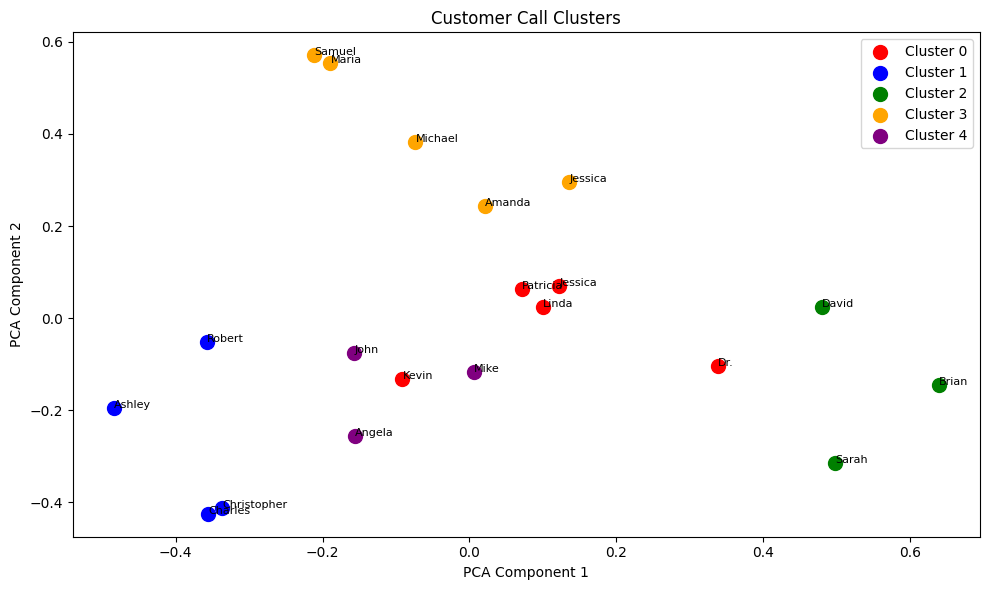


Cluster Contents:

Cluster 0:
                Name             Type Sentiment
4      Jessica Brown  Order Placement   Neutral
6       Linda Garcia        Complaint     Angry
10  Dr. Emily Carter  Product Inquiry   Neutral
11         Kevin Lee        Complaint     Angry
18  Patricia Collins  Order Placement   Neutral

Cluster 1:
                 Name        Type Sentiment
3        Robert Smith  Compliment     Happy
9   Christopher Green  Compliment     Happy
14       Ashley Perez  Compliment     Happy
19      Charles Evans  Compliment     Happy

Cluster 2:
              Name             Type Sentiment
0     Sarah Miller  Product Inquiry   Neutral
5     David Wilson  Product Inquiry  Confused
15  Brian Thompson  Product Inquiry   Neutral

Cluster 3:
                Name             Type   Sentiment
2    Maria Rodriguez  Technical Issue  Frustrated
7      Michael Brown  Technical Issue     Neutral
8       Amanda White  Order Placement       Happy
12  Jessica Williams  Technical Issue  Fr

In [39]:
# Visualize using PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X.toarray())

plt.figure(figsize=(10,6))
colors = ['red','blue' 'green', 'orange', 'purple']
for cluster in range(5):
    mask = df['Cluster'] == cluster
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        s=100
    )
    # Cutomer names as labels
    for idx in df[mask].index:
        plt.annotate(
            df['Name'][idx].split()[0],
            (X_2d[idx, 0], X_2d[idx, 1]),
            fontsize = 8
        )

plt.title('Customer Call Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

# Step 4: Show what's in each cluster
print("\nCluster Contents:")
for cluster in range(5):
    calls = df[df['Cluster'] == cluster][['Name', 'Type', 'Sentiment']]
    print(f"\nCluster {cluster}:")
    print(calls.to_string())

In [53]:
# RAG Assistant
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document   
from transformers import pipeline
import os

# Preparing docs
print("Preparing documents...")
documents = []
for idx, row in df.iterrows():
    content = f"""
    Customer: {row['Name']}
    Call Type: {row['Type']}
    Sentiment: {row['Sentiment']}
    Topic: {row['Predicted_Topic']}
    Intent: {row['Predicted_Intent']}
    Summary: {row['Summary']}
    Full Transcript: {row['Transcript']}
    """
    doc = Document(
        page_content=content,
        metadata={
            'customer': row['Name'],
            'type': row['Type'],
            'sentiment': row['Sentiment']
        }
    )
    documents.append(doc)

print(f"Prepared {len(documents)} documents")

# embeddings
print("\nLoading embedding model...")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Storing in ChromaDB
print("\nBuilding vector database...")
vectordb = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    persist_directory="./chroma_db"
)
print(f"Vector database created with {vectordb._collection.count()}")

Preparing documents...
Prepared 20 documents

Loading embedding model...


C:\Users\Landl\AppData\Local\Temp\ipykernel_5156\2408792411.py:36: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(



Building vector database...
Vector database created with 20


In [55]:
# RAG Query Function
def ask_rag(question, k=3):
    """
    Ask any question about your call center data.
    k= number of relevant transcripts to retrieve
    """
    print(f"\nQuestion: {question}")
    print("-" * 50)

    # find most relevant transcripts
    relevant_docs = vectordb.similarity_search(question, k=k)

    # Build context from retrieved docs
    context ="\n\n".join([doc.page_content for doc in relevant_docs])

    # Show what was retrieved
    print(f"Retrieved {len(relevant_docs)} relevant calls:")
    for doc in relevant_docs:
        print(f"  - {doc.metadata['customer']} ({doc.metadata['type']})")
    
    # Generate answer using a small LLM
    qa_pipeline = pipeline(
        "text2text-generation",
        model="google/flan-t5-base"
    )
    
    prompt = f"""Based on these call center transcripts, answer the question.
    
Context:
{context[:1000]}

Question: {question}

Answer:"""
    
    result = qa_pipeline(prompt, max_length=150, do_sample=False)
    answer = result[0]['generated_text']
    
    print(f"\nAnswer: {answer}")
    return answer

# Test with real questions
ask_rag("What are customers complaining about most?")
ask_rag("Which customers have technical issues?")
ask_rag("What products are customers asking about?")
ask_rag("Which customers seem most angry?")


Question: What are customers complaining about most?
--------------------------------------------------
Retrieved 3 relevant calls:
  - Linda Garcia (Complaint)
  - John Davis (Complaint)
  - Christopher Green (Compliment)


config.json: 0.00B [00:00, ?B/s]

C:\Users\Landl\anaconda3\envs\callcenter\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Landl\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTT

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]


Answer: a defective refrigerator

Question: Which customers have technical issues?
--------------------------------------------------
Retrieved 3 relevant calls:
  - Jessica Williams (Technical Issue)
  - Linda Garcia (Complaint)
  - John Davis (Complaint)

Answer: Jessica Williams

Question: What products are customers asking about?
--------------------------------------------------
Retrieved 3 relevant calls:
  - Amanda White (Order Placement)
  - Ashley Perez (Compliment)
  - Kevin Lee (Complaint)

Answer: a camera

Question: Which customers seem most angry?
--------------------------------------------------
Retrieved 3 relevant calls:
  - John Davis (Complaint)
  - Kevin Lee (Complaint)
  - Linda Garcia (Complaint)

Answer: John Davis


'John Davis'

In [56]:
# Save cluster assignments
df.to_csv('processed_calls.csv', index=False)
print("Saved with cluster assignments")

print(f"Clusters created: {df['Cluster'].nunique()}")
print(f"RAG database entries: {vectordb._collection.count()}")
print("\nYou can now ask any question about your call center data!")

# Final demo
print("\n--- Final RAG Demo ---")
questions = [
    "What are the most common customer complaints?",
    "Which customers need urgent attention?",
    "What products are mentioned most often?"
]
for q in questions:
    ask_rag(q)

Saved with cluster assignments
Clusters created: 5
RAG database entries: 20

You can now ask any question about your call center data!

--- Final RAG Demo ---

Question: What are the most common customer complaints?
--------------------------------------------------
Retrieved 3 relevant calls:
  - John Davis (Complaint)
  - Linda Garcia (Complaint)
  - Kevin Lee (Complaint)

Answer: I ordered a hard drive that was supposed to arrive three days ago. The tracking information o

Question: Which customers need urgent attention?
--------------------------------------------------
Retrieved 3 relevant calls:
  - Linda Garcia (Complaint)
  - John Davis (Complaint)
  - Amanda White (Order Placement)

Answer: The FR-4401

Question: What products are mentioned most often?
--------------------------------------------------
Retrieved 3 relevant calls:
  - Amanda White (Order Placement)
  - Ashley Perez (Compliment)
  - Patricia Collins (Order Placement)

Answer: a camera


In [ ]:
# Streamlit dashobard
import streamlit as st

# page config
st.set_page_config(
    page_title="Call Center NLP Dashboard",
    page_icon="📞",
    layout="wide"
)

# LOAD MODELS - Cache so they don't reload
@st.cache_resource
def load_spacy():
    return spacy.load('en_core_web_sm')

@st.cache_resource
def load_sentiment_model():
    return pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )

@st.cache_resource
def load_summarizer():
    return pipeline(
        "summarization",
        model="facebook/bart-large-cnn"
    )

@st.cache_resource
def load_topic_classifier():
    return pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli"
    )

@st.cache_resource
def load_keybert():
    return KeyBERT()

@st.cache_resource
def load_rag():
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )
    vectordb = Chroma(
        persist_directory="./chroma_db",
        embedding_function=embeddings
    )
    return vectordb

@st.cache_data
def load_data():
    return pd.read_csv('processed_calls.csv')

# HEADER
st.title("📞 Call Center NLP Dashboard")
st.markdown("**End-to-end NLP pipeline for call center transcript analysis**")
st.markdown("---")

# SIDEBAR
st.sidebar.title("Navigation")
tab_selection = st.sidebar.radio(
    "Choose a section:",
    ["📊 Overview & EDA",
     "🔍 Analyze a Call",
     "🤖 RAG Assistant",
     "🗂️ Cluster Explorer"]
)


# OVERVIEW & EDA
if tab_selection == "📊 Overview & EDA":
    st.header("📊 Dataset Overview")

    df = load_data()

    # Key metrics at top
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Calls", len(df))
    col2.metric("Call Types", df['Type'].nunique())
    col3.metric("Sentiment Types", df['Sentiment'].nunique())
    col4.metric("Avg Words/Call", 
                f"{df['Transcript'].apply(lambda x: len(str(x).split())).mean():.0f}")

    st.markdown("---")

    # Charts
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Sentiment Distribution")
        sentiment_counts = df['Sentiment'].value_counts()
        fig, ax = plt.subplots()
        ax.bar(sentiment_counts.index, 
               sentiment_counts.values, 
               color=['green','blue','red','orange','purple'])
        ax.set_xlabel("Sentiment")
        ax.set_ylabel("Count")
        plt.xticks(rotation=45)
        st.pyplot(fig)

    with col2:
        st.subheader("Call Type Distribution")
        type_counts = df['Type'].value_counts()
        fig, ax = plt.subplots()
        ax.pie(type_counts.values,
               labels=type_counts.index,
               autopct='%1.1f%%')
        st.pyplot(fig)

    st.markdown("---")
    st.subheader("Raw Data")
    st.dataframe(df[['Name','Type','Sentiment',
                      'Predicted_Topic','Predicted_Intent',
                      'Summary']].style.highlight_max(axis=0))

#ANALYZE A SINGLE CALL

elif tab_selection == "🔍 Analyze a Call":
    st.header("🔍 Analyze a Single Transcript")
    st.markdown("Paste any call transcript below to run the full NLP pipeline on it.")

    # Load models
    nlp = load_spacy()
    sentiment_model = load_sentiment_model()
    summarizer = load_summarizer()
    topic_classifier = load_topic_classifier()
    kw_model = load_keybert()

    # Text input
    user_transcript = st.text_area(
        "Paste transcript here:",
        height=200,
        placeholder="Hello, I'm calling about my order..."
    )

    if st.button("🚀 Analyze", type="primary"):
        if user_transcript.strip() == "":
            st.warning("Please enter a transcript first.")
        else:
            st.markdown("---")

            # Run all models
            with st.spinner("Running NLP pipeline..."):

                # 1. PII Redaction
                doc = nlp(user_transcript)
                redacted = user_transcript
                for ent in doc.ents:
                    if ent.label_ in ['PERSON']:
                        redacted = redacted.replace(
                            ent.text, '[CUSTOMER_NAME]'
                        )
                redacted = re.sub(r'\b\d{6}\b', '[ORDER_NUMBER]', redacted)

                # 2. Sentiment
                sentiment_result = sentiment_model(user_transcript[:512])[0]

                # 3. Summary
                if len(user_transcript.split()) > 30:
                    summary_result = summarizer(
                        user_transcript[:1024],
                        max_length=60,
                        min_length=20,
                        do_sample=False
                    )[0]['summary_text']
                else:
                    summary_result = "Transcript too short to summarize"

                # 4. Topic
                topic_labels = ['product inquiry','complaint',
                               'technical issue','compliment',
                               'order placement']
                topic_result = topic_classifier(
                    user_transcript[:512],
                    candidate_labels=topic_labels
                )['labels'][0]

                # 5. Intent
                intent_labels = ['get information','file a complaint',
                                'request refund','cancel order',
                                'get technical support',
                                'give positive feedback']
                intent_result = topic_classifier(
                    user_transcript[:512],
                    candidate_labels=intent_labels
                )['labels'][0]

                # 6. Keywords
                keywords = kw_model.extract_keywords(
                    user_transcript,
                    keyphrase_ngram_range=(1,2),
                    stop_words='english',
                    top_n=5
                )
                keyword_list = [kw[0] for kw in keywords]

            # Display results
            col1, col2, col3 = st.columns(3)
            col1.metric("Sentiment", sentiment_result['label'])
            col2.metric("Topic", topic_result.title())
            col3.metric("Intent", intent_result.title())

            st.markdown("---")

            col1, col2 = st.columns(2)
            with col1:
                st.subheader("📝 Summary")
                st.info(summary_result)

                st.subheader("🔑 Keywords")
                for kw in keyword_list:
                    st.badge(kw)

            with col2:
                st.subheader("🔒 PII Redacted Version")
                st.success(redacted)

                st.subheader("🏷️ Named Entities Found")
                for ent in doc.ents:
                    st.write(f"**{ent.text}** → {ent.label_}")

# RAG ASSISTANT
elif tab_selection == "🤖 RAG Assistant":
    st.header("🤖 RAG Assistant")
    st.markdown("Ask any question about your call center data.")

    vectordb = load_rag()
    qa_pipeline = pipeline(
        "text2text-generation",
        model="google/flan-t5-base"
    )

    # Chat history using session state
    if 'chat_history' not in st.session_state:
        st.session_state.chat_history = []

    # Suggested questions
    st.subheader("💡 Try these questions:")
    col1, col2, col3 = st.columns(3)
    if col1.button("What are common complaints?"):
        st.session_state.current_q = "What are common complaints?"
    if col2.button("Which customers are angry?"):
        st.session_state.current_q = "Which customers are angry?"
    if col3.button("What products are mentioned?"):
        st.session_state.current_q = "What products are mentioned?"

    # Question input
    question = st.text_input(
        "Or type your own question:",
        value=st.session_state.get('current_q', '')
    )

    if st.button("Ask 🔍"):
        if question:
            with st.spinner("Searching transcripts..."):
                # Retrieve
                relevant_docs = vectordb.similarity_search(question, k=3)
                context = "\n\n".join(
                    [doc.page_content for doc in relevant_docs]
                )

                # Generate answer
                prompt = f"""Based on call center transcripts, answer briefly.
Context: {context[:800]}
Question: {question}
Answer:"""
                answer = qa_pipeline(
                    prompt, max_length=100, do_sample=False
                )[0]['generated_text']

                # Save to history
                st.session_state.chat_history.append({
                    'question': question,
                    'answer': answer,
                    'sources': [f"{d.metadata['customer']} ({d.metadata['type']})"
                               for d in relevant_docs]
                })

    # Display chat history
    for chat in reversed(st.session_state.chat_history):
        with st.container():
            st.markdown(f"**Q:** {chat['question']}")
            st.markdown(f"**A:** {chat['answer']}")
            st.caption(f"Sources: {', '.join(chat['sources'])}")
            st.markdown("---")

# cUSTER EXPLORER
elif tab_selection == "🗂️ Cluster Explorer":
    st.header("🗂️ Customer Cluster Explorer")

    df = load_data()

    # Rebuild clusters
    vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
    X = vectorizer.fit_transform(df['Transcript'])
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    df['Cluster'] = kmeans.fit_predict(X)
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X.toarray())

    # Scatter plot
    st.subheader("Customer Call Clusters (PCA Visualization)")
    colors = ['red','blue','green','orange','purple']
    fig, ax = plt.subplots(figsize=(10,6))
    for cluster in range(5):
        mask = df['Cluster'] == cluster
        ax.scatter(X_2d[mask,0], X_2d[mask,1],
                  c=colors[cluster],
                  label=f'Cluster {cluster}', s=100)
        for idx in df[mask].index:
            ax.annotate(df['Name'][idx].split()[0],
                       (X_2d[idx,0], X_2d[idx,1]),
                       fontsize=8)
    ax.legend()
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    st.pyplot(fig)

    # Cluster filter
    st.markdown("---")
    selected_cluster = st.selectbox(
        "Select a cluster to explore:",
        options=[0,1,2,3,4],
        format_func=lambda x: f"Cluster {x}"
    )

    cluster_df = df[df['Cluster'] == selected_cluster]
    st.subheader(f"Cluster {selected_cluster} — {len(cluster_df)} calls")
    st.dataframe(cluster_df[['Name','Type','Sentiment',
                              'Predicted_Topic','Summary']])